In [48]:
import wbgapi as wb
import pandas as pd
import numpy as np

pop_gdp_data = wb.data.DataFrame(["SP.POP.GROW", "NY.GDP.MKTP.KD.ZG", "FP.CPI.TOTL.ZG"], 'RWA', mrv=50)
pop_gdp_data = pop_gdp_data.T
pop_gdp_data.columns = ["Population Growth", "GDP Growth", "Inflation Rate"]
pop_gdp_data["Next Year GDP Growth"] = pop_gdp_data["GDP Growth"].shift(-1)
pop_gdp_data.index = pop_gdp_data.index.str.replace("YR", "", regex=False)
pop_gdp_data.index = pd.to_datetime(pop_gdp_data.index, format='%Y')
pop_gdp_data_copy = pop_gdp_data.copy()
pop_gdp_data.dropna(inplace=True)
pop_gdp_data

,Population Growth,GDP Growth,Inflation Rate,Next Year GDP Growth
1975-01-01,30.226047,-2.113825,2.940107,19.504577
1976-01-01,7.165862,19.504577,2.955757,1.994109
1977-01-01,13.655147,1.994109,2.953985,9.150841
1978-01-01,13.270534,9.150841,2.961517,11.869908
1979-01-01,15.673329,11.869908,3.019777,8.951612
1980-01-01,7.249393,8.951612,3.106028,5.436199
1981-01-01,6.450664,5.436199,3.198125,1.810846
1982-01-01,12.565137,1.810846,3.280348,5.980350
1983-01-01,6.593002,5.980350,3.336185,-4.240773
1984-01-01,5.369570,-4.240773,3.368620,4.402748


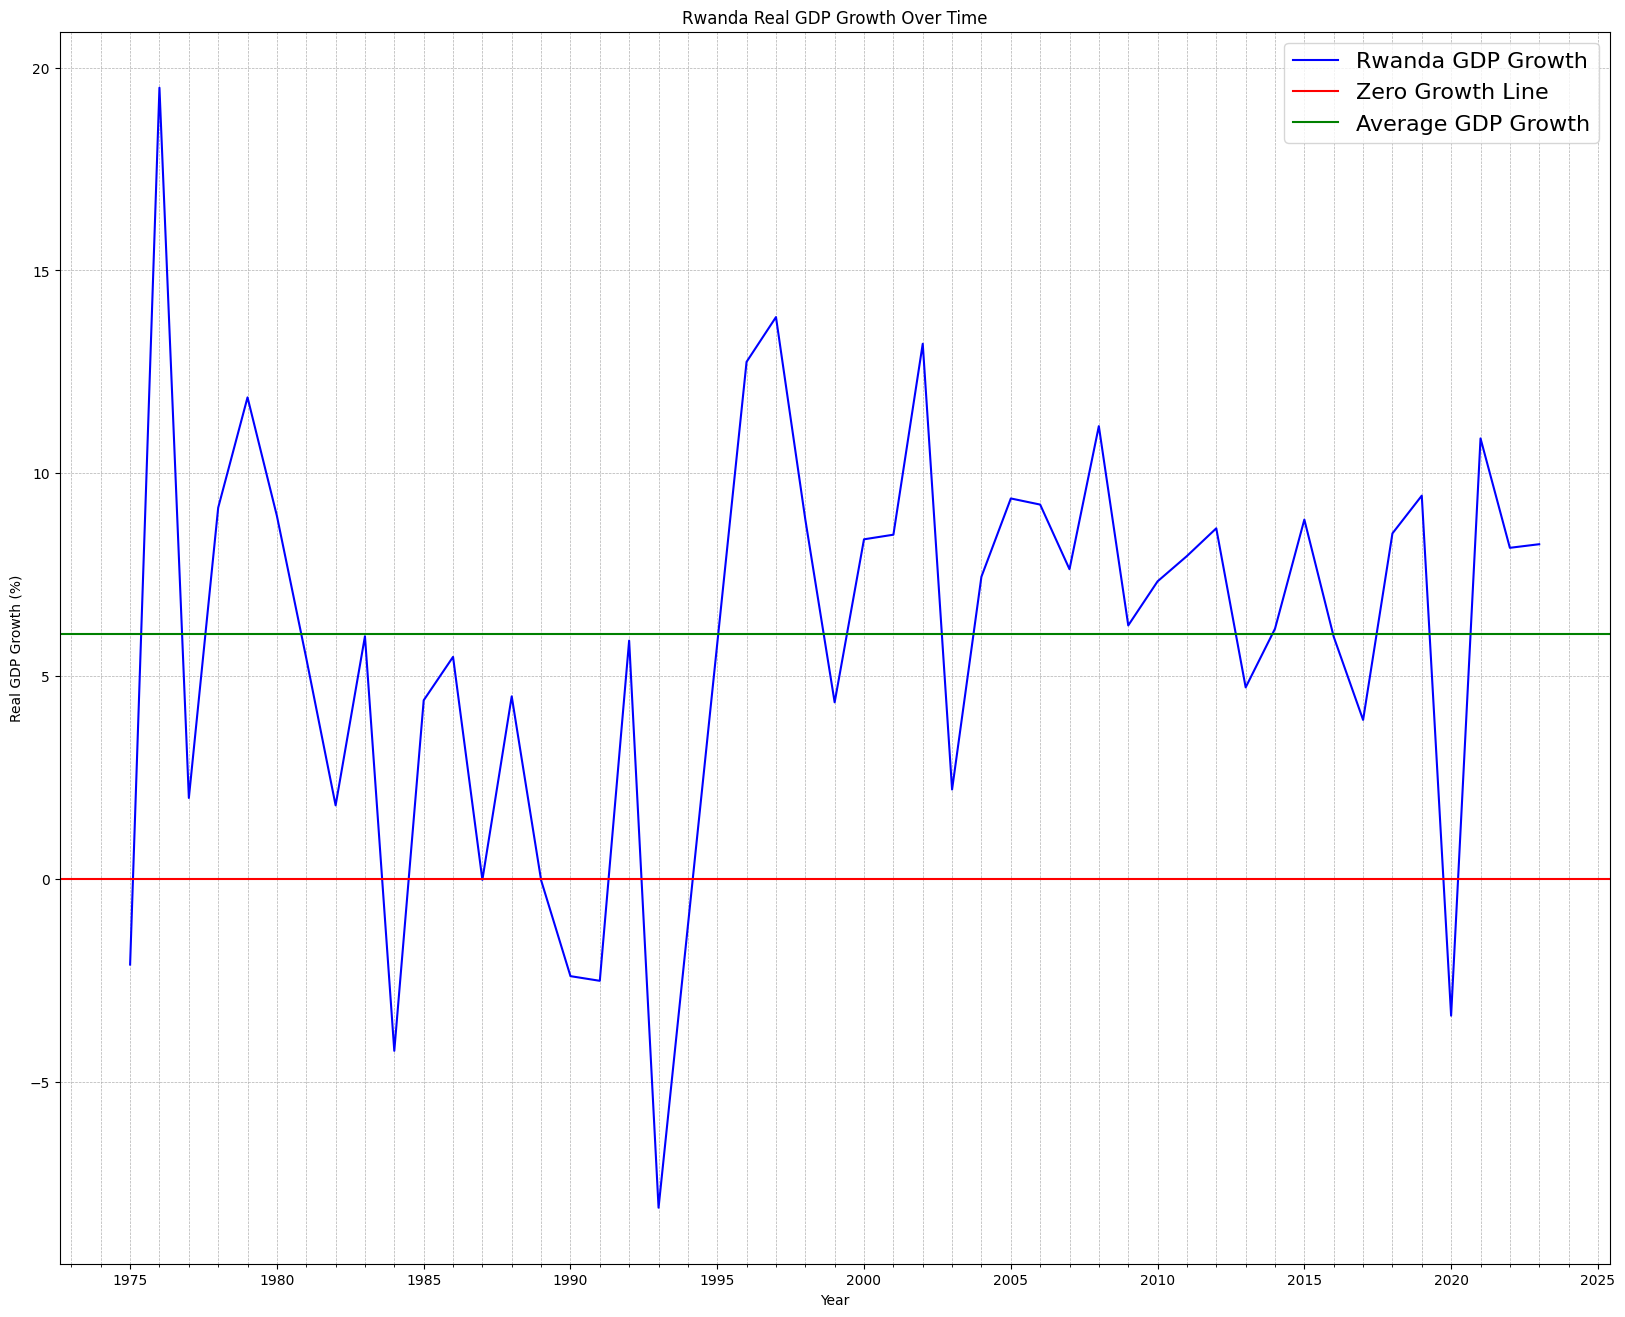

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(20, 16))
plt.plot(pop_gdp_data["GDP Growth"], label="Rwanda GDP Growth", color="blue")

plt.axhline(0, color="red", label="Zero Growth Line")
plt.axhline(pop_gdp_data["GDP Growth"].mean(), color="green", label="Average GDP Growth")

plt.xlabel("Year")
plt.ylabel("Real GDP Growth (%)")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

plt.title("Rwanda Real GDP Growth Over Time")
plt.legend(fontsize=16)
plt.show()

In [50]:
import statsmodels.tsa.arima.model as smt
arima_model = smt.ARIMA(pop_gdp_data["GDP Growth"], order=(2, 0, 2))
forecast_model = arima_model.fit()
forecast_model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             GDP Growth   No. Observations:                   47
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -141.184
Date:                Sun, 31 Aug 2025   AIC                            294.369
Time:                        01:03:20   BIC                            305.469
Sample:                             0   HQIC                           298.546
                                 - 47                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1170      1.034      5.917      0.000       4.091       8.143
ar.L1          0.8180      0.292      2.804      0.005       0.246       1.390
ar.L2         -0.5527      0.228     -2.421      0.015      -1.000      -0.105
ma.L1         -0.9380      0.221     -4.247      0.000      -1.371      -0.505
ma.L2          0.8719      0.168      5.177      0.000       0.542       1.202
sigma2        23.3105      5.179      4.501      0.000      13.160      33.461
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.01
Prob(Q):                              0.91   Prob(JB):                         1.00
Heteroskedasticity (H):               0.36   Skew:                             0.03
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
last_obs = len(pop_gdp_data) - 1
start = last_obs
end = last_obs + 8
forecasts = forecast_model.predict(start=start, end=end, typ='levels')
forecasts

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


46    5.303056
47    6.265814
48    7.628588
49    7.271249
50    6.225696
51    5.567929
52    5.607771
53    6.003929
54    6.305972
Name: predicted_mean, dtype: float64

In [52]:
last_year = pop_gdp_data.index[-1].year
forecast_index = pd.date_range(
    start=f"{last_year}-01-01",
    periods=9,
    freq="YS"  # Year Start frequency
)

forecasts.index = forecast_index

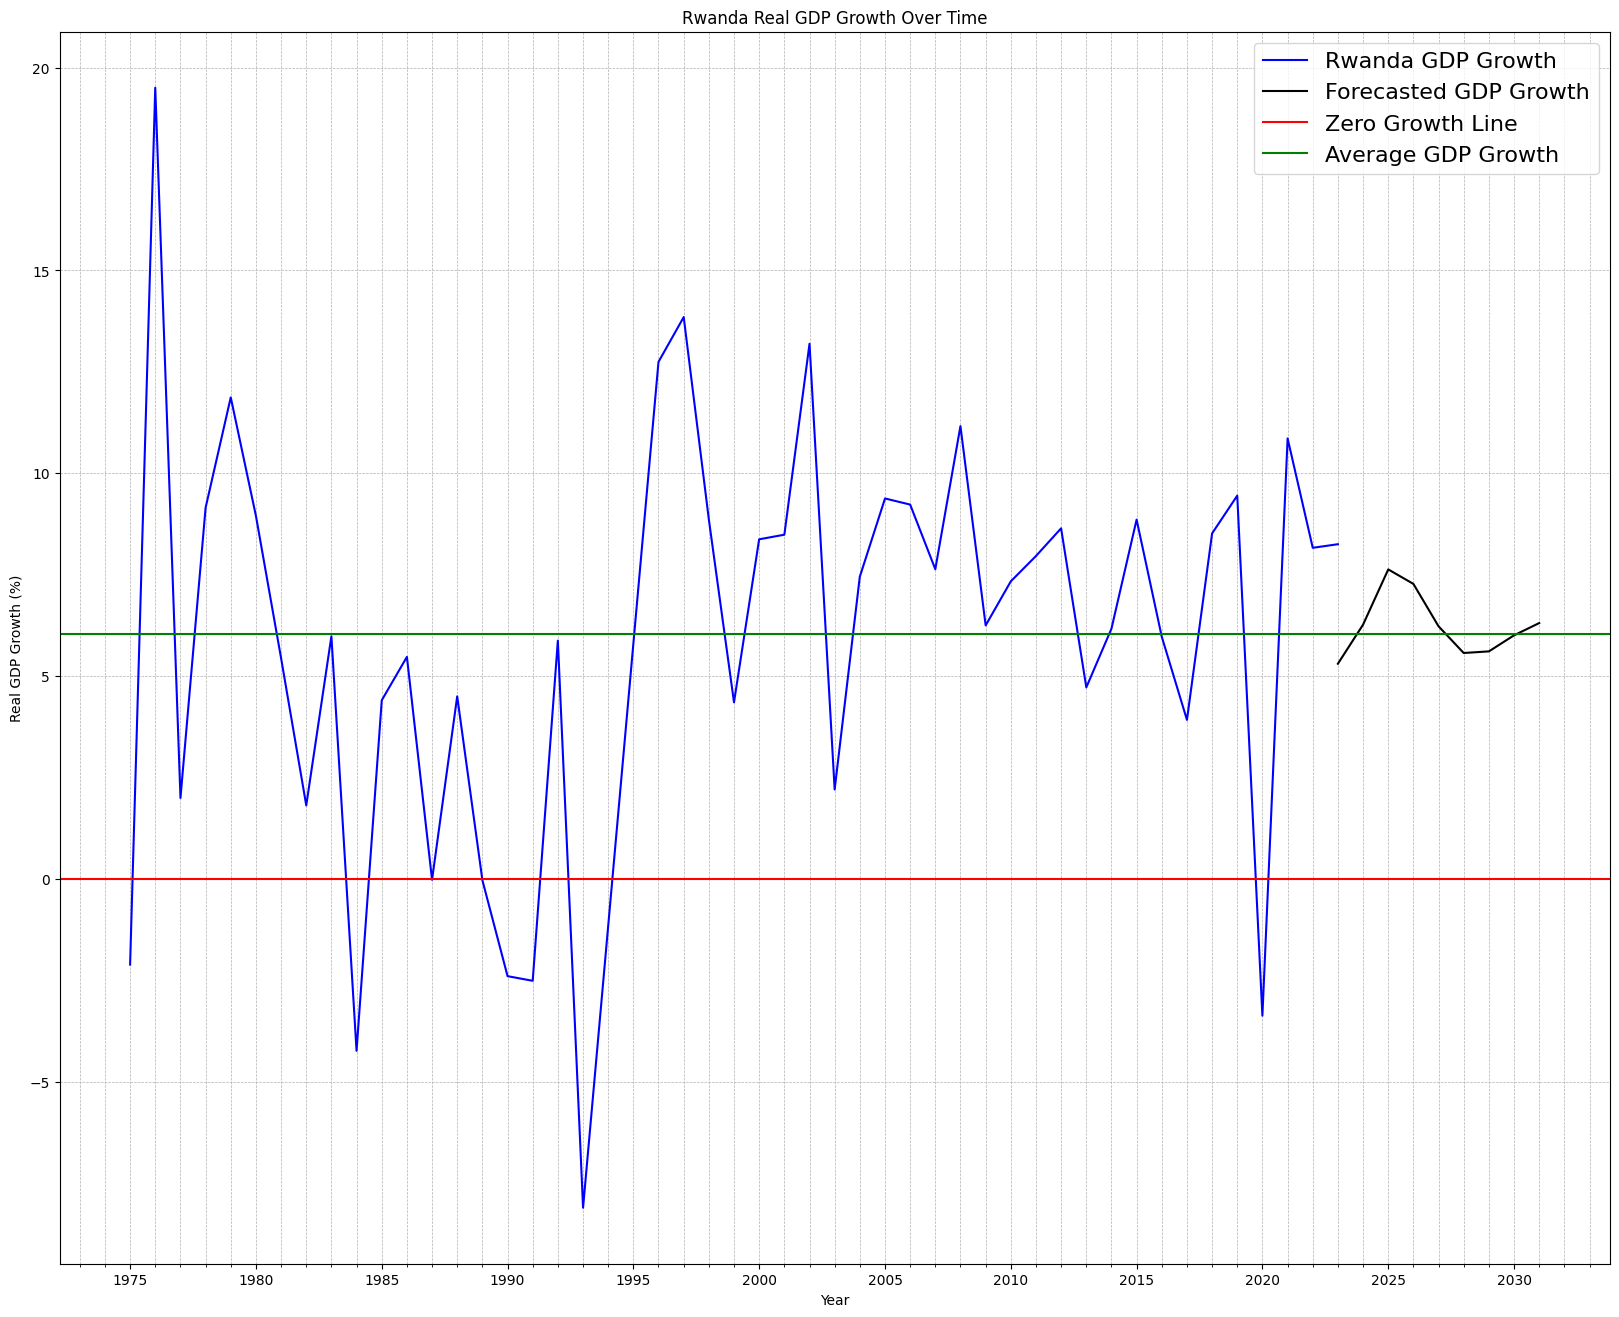

In [53]:
plt.figure(figsize=(20, 16))
plt.plot(pop_gdp_data["GDP Growth"], label="Rwanda GDP Growth", color="blue")
plt.plot(forecasts, label="Forecasted GDP Growth", color="black")

plt.axhline(0, color="red", label="Zero Growth Line")
plt.axhline(pop_gdp_data["GDP Growth"].mean(), color="green", label="Average GDP Growth")

plt.xlabel("Year")
plt.ylabel("Real GDP Growth (%)")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

plt.title("Rwanda Real GDP Growth Over Time")
plt.legend(fontsize=16)
plt.show()